In [1]:
import subprocess, sys
from pathlib import Path

def mp4_to_wav(mp4_path, wav_path=None, sample_rate=44100, mono=False):
    src = Path(mp4_path)
    dst = Path(wav_path) if wav_path else src.with_suffix(".wav")
    cmd = ["ffmpeg", "-y", "-i", str(src), "-vn", "-acodec", "pcm_s16le", "-ar", str(sample_rate)]
    if mono:
        cmd += ["-ac", "1"]
    subprocess.run(cmd + [str(dst)], check=True)
    return dst

mp4_to_wav("20261001-212B_2160p60.mp4", wav_path="test_wav.wav")
mp4_to_wav("VID_20261001_181504.mp4", wav_path="test_212.wav")

WindowsPath('test_212.wav')

Text(0, 0.5, 'RPM')

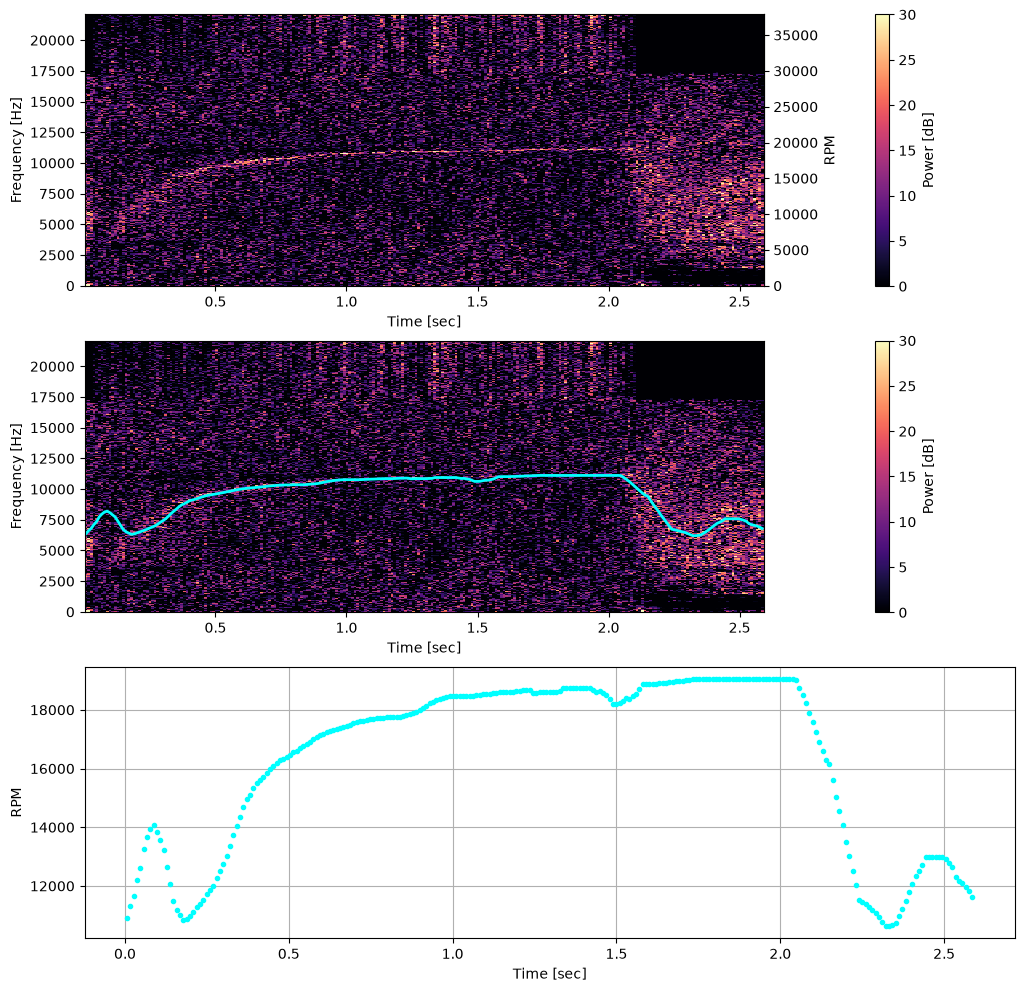

In [2]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy import interpolate


WAV, BLADES = "test_wav.wav", 35
N, H = 512, 256          # window, hop
JUMP_HZ, MIN_DB = 400, 8   # max ridge move per frame, tone-lost threshold

# load
fs, x = wavfile.read(WAV)
x = x.astype(float)
if x.ndim > 1: x = x[:, 0]      # keep left channel only
from scipy.signal import spectrogram

x = x[int(2.9*fs):int(5.5*fs)]
f, t, Sxx = spectrogram(x = x, fs = fs, nfft=N, nperseg=N)

W = 20*np.log10(Sxx + 1e-12)
W -= np.median(W, axis=1, keepdims=True)
W -= np.median(W, axis=0, keepdims=True)
band = (f >= 5000) & (f <= 12500)
Wb, fb = W[band], f[band]
line = np.where(Wb.max(axis=0) > 12, fb[Wb.argmax(axis=0)], np.nan)
# T0, T1 = 14.0, 28.0                       # read off your plot
# line[(t < T0) | (t > T1)] = np.nan

import pandas as pd
line = pd.Series(line).rolling(9, center=True, min_periods=3).median()
line = line.rolling(9, center=True, min_periods=3).mean().to_numpy()

FPS = 60
rpm = FPS * line / BLADES

fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
pcm = ax.pcolormesh(t, f, W, cmap="magma", vmin=0, vmax=30)
fig.colorbar(pcm, ax=ax, label="Power [dB]", pad=0.12)
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("Time [sec]")

pcm2 = ax2.pcolormesh(t, f, W, cmap="magma", vmin=0, vmax=30)
ax2.plot(t, line, color="cyan", lw=2)
fig.colorbar(pcm2, ax=ax2, label="Power [dB]", pad=0.12)
ax2.set_ylabel("Frequency [Hz]")
ax2.set_xlabel("Time [sec]")

ax3.plot(t, rpm, '.',color="cyan", lw=2)
ax3.grid()
ax3.set_ylabel("RPM")
ax3.set_xlabel("Time [sec]")


sec = ax.secondary_yaxis("right", functions=(lambda hz: 60 * hz / BLADES,
                                             lambda rpm: rpm * BLADES / 60))
sec.set_ylabel("RPM")

Text(0, 0.5, 'RPM')

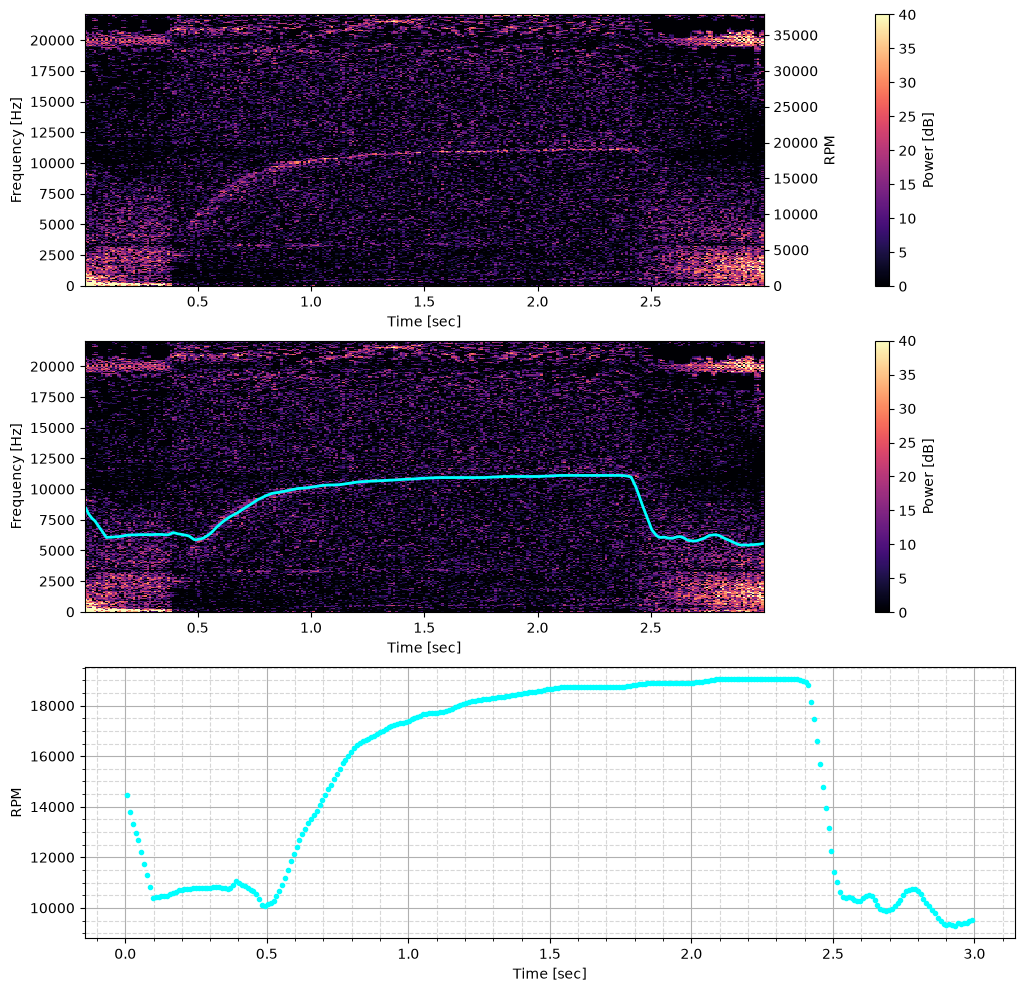

In [28]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy import interpolate


WAV, BLADES = "test_212.wav", 35
N, H = 512, 256          # window, hop
JUMP_HZ, MIN_DB = 400, 8   # max ridge move per frame, tone-lost threshold

# load
fs, x = wavfile.read(WAV)
x = x.astype(float)
if x.ndim > 1: x = x[:, 0]      # keep left channel only
from scipy.signal import spectrogram

x = x[int(10*fs):int(13*fs)]
f, t, Sxx = spectrogram(x = x, fs = fs, nfft=N, nperseg=N)


W = 20*np.log10(Sxx + 1e-12)
W -= np.median(W, axis=1, keepdims=True)
W -= np.median(W, axis=0, keepdims=True)
band = (f >= 5000) & (f <= 12500)
Wb, fb = W[band], f[band]
line = np.where(Wb.max(axis=0) > 12, fb[Wb.argmax(axis=0)], np.nan)
# T0, T1 = 14.0, 28.0                       # read off your plot
# line[(t < T0) | (t > T1)] = np.nan

import pandas as pd
line = pd.Series(line).rolling(9, center=True, min_periods=3).median()
line = line.rolling(9, center=True, min_periods=3).mean().to_numpy()

FPS = 60
rpm = FPS * line / BLADES

fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
pcm = ax.pcolormesh(t, f, W, cmap="magma", vmin=0, vmax=40)
fig.colorbar(pcm, ax=ax, label="Power [dB]", pad=0.12)
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("Time [sec]")

pcm2 = ax2.pcolormesh(t, f, W, cmap="magma", vmin=0, vmax=40)
ax2.plot(t, line, color="cyan", lw=2)
fig.colorbar(pcm2, ax=ax2, label="Power [dB]", pad=0.12)
ax2.set_ylabel("Frequency [Hz]")
ax2.set_xlabel("Time [sec]")

ax3.plot(t, rpm, '.',color="cyan", lw=2)
ax3.grid(True, which="major")
ax3.grid(True, which="minor", ls="--", alpha=0.5)
ax3.minorticks_on()
ax3.set_ylabel("RPM")
ax3.set_xlabel("Time [sec]")


sec = ax.secondary_yaxis("right", functions=(lambda hz: 60 * hz / BLADES,
                                             lambda rpm: rpm * BLADES / 60))
sec.set_ylabel("RPM")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\Martin\AppData\Local\Temp\ipykernel_32980\648057214.py:53: RuntimeWarning: invalid value encountered in sqrt
  mdot_gg_ipa_dp = gg_ipa_cda * np.sqrt(2 * ipa_density * dp_gg_fuel * BAR )


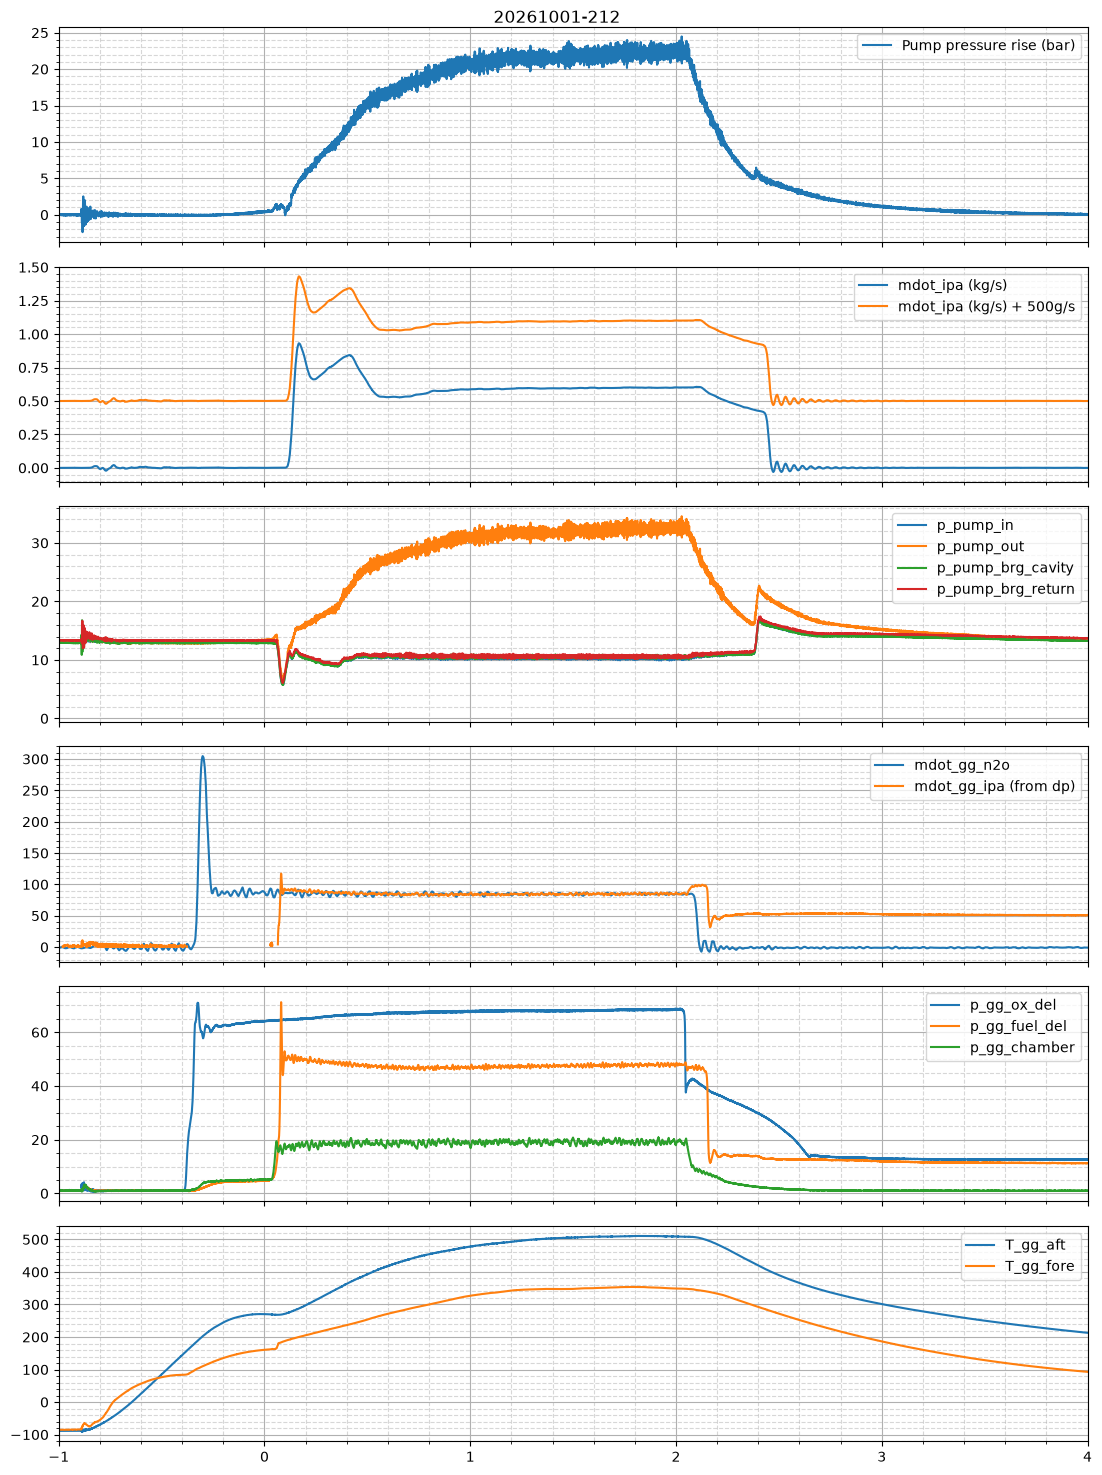

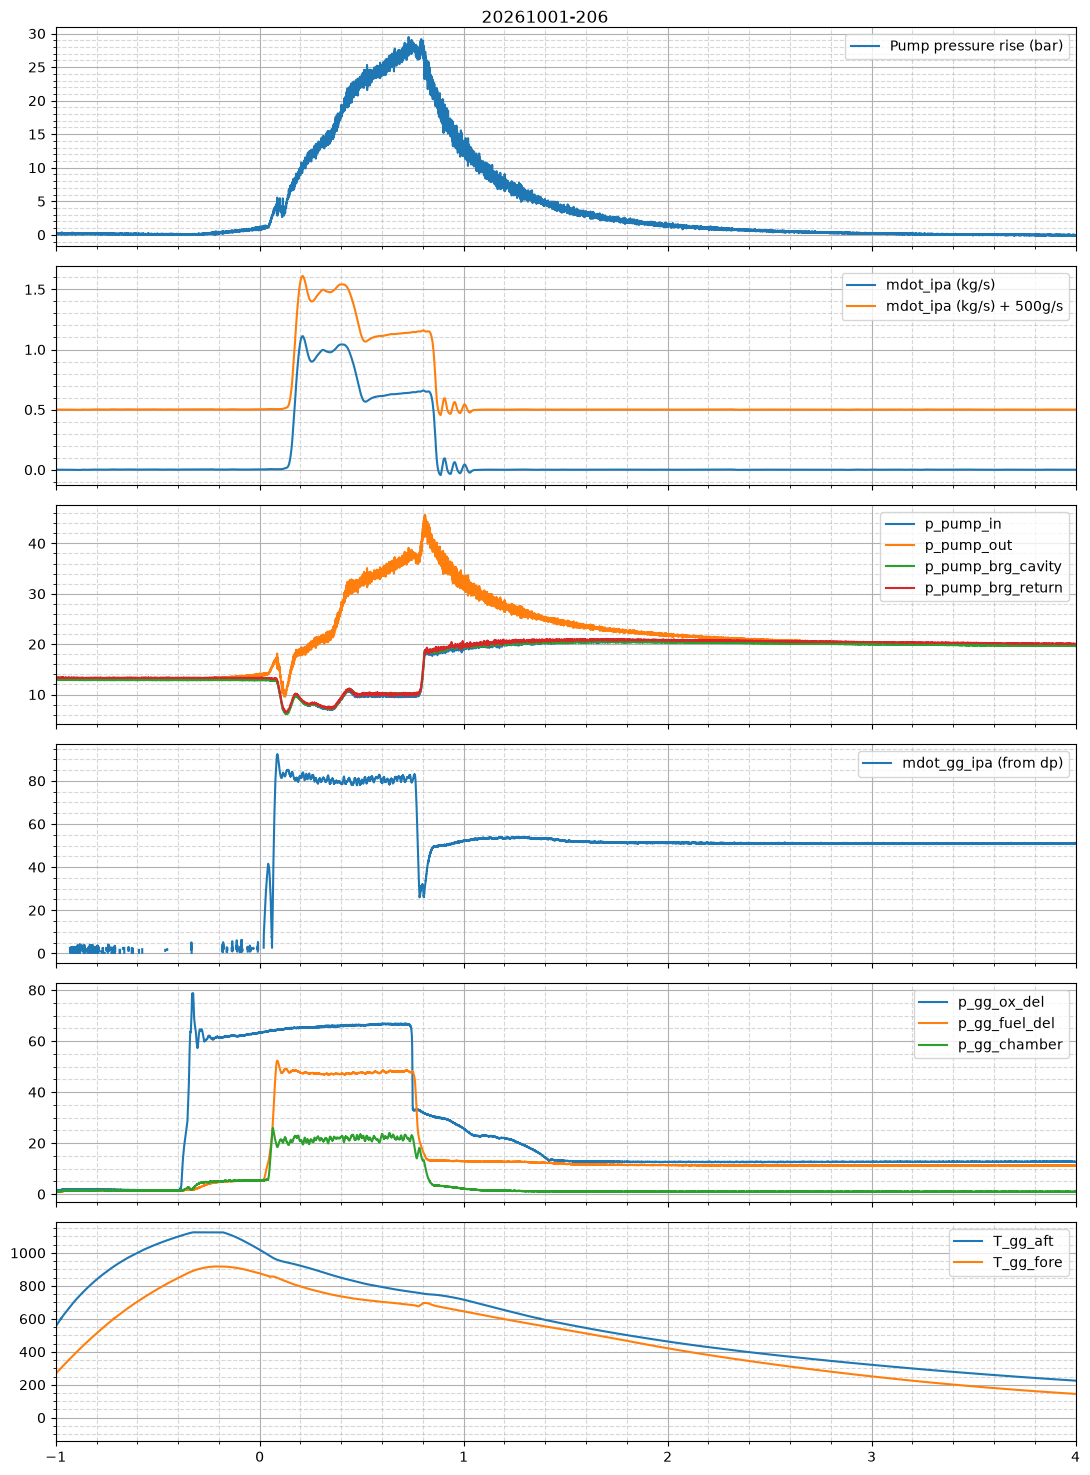

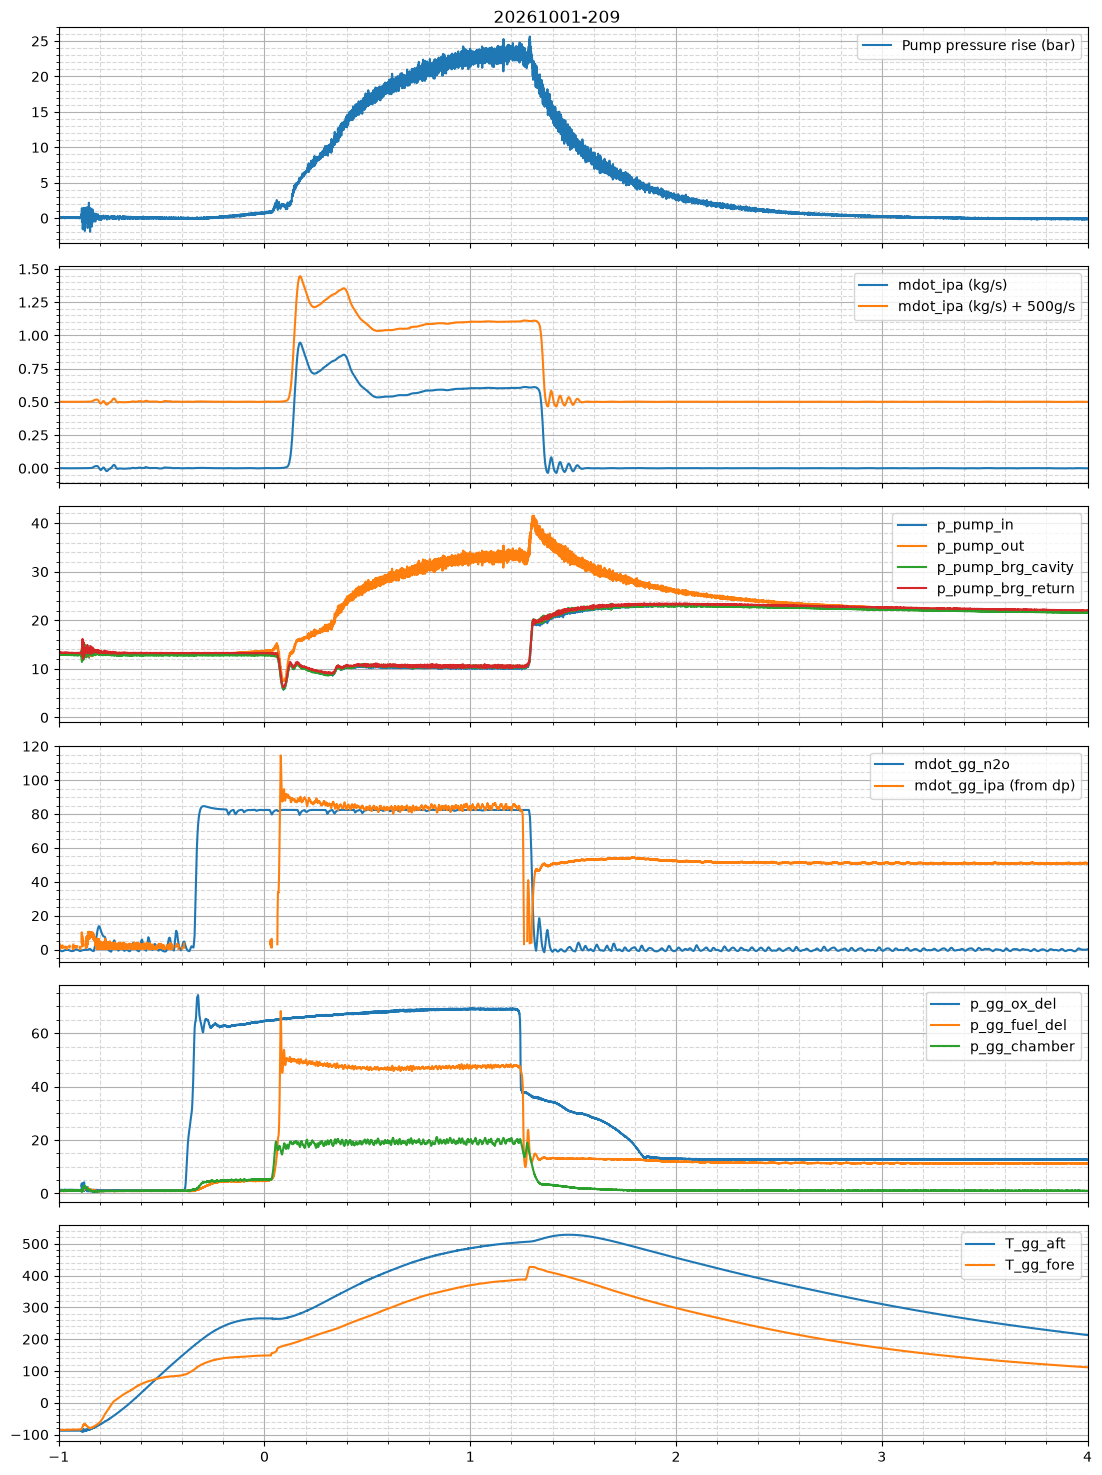

In [10]:
%load_ext autoreload
%autoreload 2
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from otp.experiments.loaders.airborne import load_run

from data.OT2.ot2 import CHANNEL_MAP as OT2_CHANNEL_MAP, DATA_PATH as OT2_DATA_PATH
ot2_run = load_run(OT2_DATA_PATH, OT2_CHANNEL_MAP, "20250709-002")
from data.Integza20261001.integza20261001 import CHANNEL_MAP as INTEGZA_CHANNEL_MAP, DATA_PATH_206, DATA_PATH_209, DATA_PATH_212

def plot():

    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(6, 1, figsize=(11, 15), sharex=True)

    fig.suptitle(integza_run.run_id)
    axs[0].set_xlim(-1, 4)

    axs[0].plot(integza_run["p_pump_out"].t,integza_run["p_pump_out"].v-integza_run["p_pump_in"].v, label="Pump pressure rise (bar)")
    axs[1].plot(integza_run["mdot_ipa"].t, integza_run["mdot_ipa"].v, label="mdot_ipa (kg/s)")
    axs[1].plot(integza_run["mdot_ipa"].t, integza_run["mdot_ipa"].v + 0.5, label="mdot_ipa (kg/s) + 500g/s")

    for n in ("p_pump_in", "p_pump_out", "p_pump_brg_cavity", "p_pump_brg_return"):
        axs[2].plot(integza_run[n].t, integza_run[n].v, label=f"{n}")

    if integza_run.run_id != "20261001-206":
        axs[3].plot(integza_run["mdot_gg_n2o"].t, integza_run["mdot_gg_n2o"].v, label="mdot_gg_n2o")
    # use ipa pressure to estimate mdot
    dp_gg_fuel = integza_run["p_gg_fuel_del"].v - integza_run["p_gg_chamber"].v
    dp_gg_n2o = integza_run["p_gg_ox_del"].v - integza_run["p_gg_chamber"].v

    gg_n2o_cda = 1.07e-6
    gg_ipa_cda = 1.27e-6
    ipa_density = 781.6
    # n2o_density = 1004

    from pyfluids import FluidsList, Input

    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent.parent))
    from otp.propellants.propellant import Propellant
    from otp.core.units import K_TO_C, BAR
    n2o = Propellant("NitrousOxide", FluidsList.NitrousOxide, 298.15, 70*1e5)


    # axs[3].plot()

    # n2o_density = np.array([n2o.fluid.with_state(Input.pressure(p*BAR), Input.temperature(t)).density for p, t in zip(integza_run["p_gg_ox_del"].v[::100], integza_run["T_gg_ox_del"].v[::100])])
    # n2o is definitely supercharged, so this is not accurate

    mdot_gg_ipa_dp = gg_ipa_cda * np.sqrt(2 * ipa_density * dp_gg_fuel * BAR )
    # mdot_gg_n2o_dp = gg_n2o_cda * np.sqrt(2 * n2o_density * dp_gg_n2o[::100] * BAR )
    # axs[3].plot(integza_run["mdot_gg_n2o"].t[::100], mdot_gg_n2o_dp*1000, label="mdot_gg_n2o (from dp)")
    axs[3].plot(integza_run["p_gg_fuel_del"].t, mdot_gg_ipa_dp*1000, label="mdot_gg_ipa (from dp)")

    # axs[4].plot(integza_run["T_gg_ox_del"].t[::100], density, label="n2o density (kg/m3)")
    for n in ["p_gg_ox_del", "p_gg_fuel_del", "p_gg_chamber"]:
        axs[4].plot(integza_run[n].t, integza_run[n].v, label=f"{n}")

    # for n in ["p_n2o_tank"]:
    #     axs[4].plot(integza_run[n].t, integza_run[n].v, label=f"{n} ({integza_run[n].source})")

    # for n in ["T_n2o_tank"]:
    #     axs[5].plot(integza_run[n].t, integza_run[n].v, label=f"{n} ({integza_run[n].source})")

    for n in ["T_gg_aft", "T_gg_fore"]:
        axs[5].plot(integza_run[n].t, integza_run[n].v, label=f"{n}")

    for ax in axs:
        ax.legend(loc="upper right")
        ax.grid(True, which="major")
        ax.grid(True, which="minor", ls="--", alpha=0.5)
        ax.minorticks_on()
    fig.tight_layout()

integza_run = load_run(DATA_PATH_212, INTEGZA_CHANNEL_MAP, "20261001-212")
plot()
integza_run = load_run(DATA_PATH_206, INTEGZA_CHANNEL_MAP, "20261001-206")
plot()
integza_run = load_run(DATA_PATH_209, INTEGZA_CHANNEL_MAP, "20261001-209")
plot()
